# Fashion MNIST Classifier using CNN (Convolutional Neural Networks)

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader

from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt
import pandas as pd

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

torch.manual_seed(42)

In [2]:
train_data = datasets.FashionMNIST(
    root="../data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="../data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

print(f"Length of train data: {len(train_data)}")
print(f"Length of test data: {len(test_data)}")

Length of train data: 60000
Length of test data: 10000


In [3]:
class_names = train_data.classes
print(class_names)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [4]:
BATCH_SIZE = 32

train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Length of train_dataloader: {len(train_dataloader)}, No. of images per batch: {BATCH_SIZE}")
print(f"Length of test_dataloader: {len(test_dataloader)}, No. of images per batch: {BATCH_SIZE}")

Length of train_dataloader: 1875, No. of images per batch: 32
Length of test_dataloader: 313, No. of images per batch: 32


In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")

Device : cuda


In [7]:
from src.models import BaselineCNN

model = BaselineCNN().to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=model.parameters(),
    lr=0.0005
)

model

BaselineCNN(
  (conv_block): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12544, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [8]:
from torchmetrics import Accuracy, Precision, Recall, F1Score

train_metrics = {
    "accuracy": Accuracy(task="multiclass", num_classes=10).to(device),
    "precision": Precision(task="multiclass", num_classes=10, average="weighted").to(device),
    "recall": Recall(task="multiclass", num_classes=10, average="weighted").to(device),
    "f1": F1Score(task="multiclass", num_classes=10, average="weighted").to(device)
}

test_metrics = {
    "accuracy": Accuracy(task="multiclass", num_classes=10).to(device),
    "precision": Precision(task="multiclass", num_classes=10, average="weighted").to(device),
    "recall": Recall(task="multiclass", num_classes=10, average="weighted").to(device),
    "f1": F1Score(task="multiclass", num_classes=10, average="weighted").to(device)
}

In [9]:
history = {
    "train": [],
    "test": []
}

In [10]:
from src.train import train_step, test_step

epochs = 20

for epoch in range(epochs):

    print(f"\nEpoch {epoch + 1}/{epochs}")
    print("-" * 30)

    train_results = train_step(
        model=model,
        dataloader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        metrics=train_metrics,
        device=device
    )

    test_results = test_step(
        model=model,
        dataloader=test_dataloader,
        loss_fn=loss_fn,
        metrics=test_metrics,
        device=device
    )

    history["train"].append(train_results)
    history["test"].append(test_results)

    print(
        f"Train Loss: {train_results['loss']:.4f} | "
        f"Train Acc: {train_results['accuracy']:.4f} | "
        f"Train Precision: {train_results['precision']:.4f} | "
        f"Train Recall: {train_results['recall']:.4f} | "
        f"Train F1: {train_results['f1']:.4f}"
    )

    print(
        f"Test Loss: {test_results['loss']:.4f} | "
        f"Test Acc: {test_results['accuracy']:.4f} | "
        f"Test Precision: {test_results['precision']:.4f} | "
        f"Test Recall: {test_results['recall']:.4f} | "
        f"Test F1: {test_results['f1']:.4f}"
    )


Epoch 1/20
------------------------------
Looked at 0 / 60000 samples
Looked at 12800 / 60000 samples
Looked at 25600 / 60000 samples
Looked at 38400 / 60000 samples
Looked at 51200 / 60000 samples
Train Loss: 0.3871 | Train Acc: 0.8617 | Train Precision: 0.8606 | Train Recall: 0.8617 | Train F1: 0.8609
Test Loss: 0.3024 | Test Acc: 0.8919 | Test Precision: 0.8944 | Test Recall: 0.8919 | Test F1: 0.8881

Epoch 2/20
------------------------------
Looked at 0 / 60000 samples
Looked at 12800 / 60000 samples
Looked at 25600 / 60000 samples
Looked at 38400 / 60000 samples
Looked at 51200 / 60000 samples
Train Loss: 0.2405 | Train Acc: 0.9122 | Train Precision: 0.9117 | Train Recall: 0.9121 | Train F1: 0.9118
Test Loss: 0.2491 | Test Acc: 0.9099 | Test Precision: 0.9102 | Test Recall: 0.9099 | Test F1: 0.9091

Epoch 3/20
------------------------------
Looked at 0 / 60000 samples
Looked at 12800 / 60000 samples
Looked at 25600 / 60000 samples
Looked at 38400 / 60000 samples
Looked at 51200 /

In [11]:
import pandas as pd

train_df = pd.DataFrame(history["train"])
test_df = pd.DataFrame(history["test"])

train_df.insert(0, "epoch", range(1, epochs + 1))
test_df.insert(0, "epoch", range(1, epochs + 1))

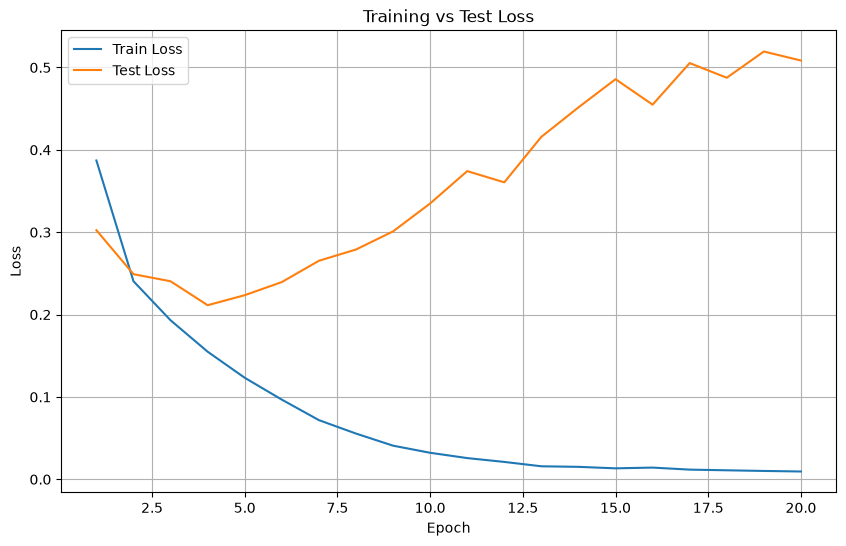

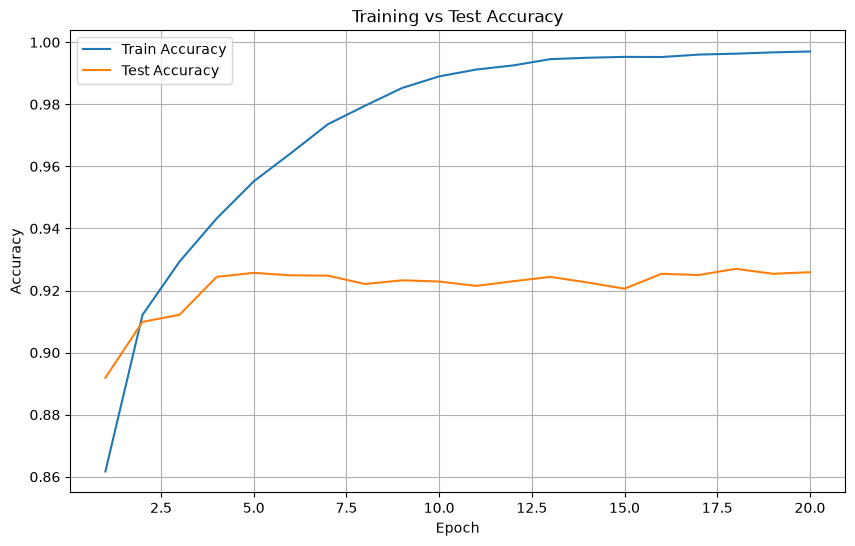

In [23]:
from src.plots import plot_metric

plot_metric(history, "loss")
plot_metric(history, "accuracy")

In [19]:
model.eval()

all_images = []
all_preds = []
all_labels = []

with torch.inference_mode():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)

        logits = model(X)
        preds = logits.argmax(dim=1)

        all_images.append(X.cpu())
        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())

all_images = torch.cat(all_images)
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

correct_indices = torch.where(all_preds == all_labels)[0]
wrong_indices = torch.where(all_preds != all_labels)[0]

print("Correct:", len(correct_indices))
print("Wrong:", len(wrong_indices))

Correct: 9259
Wrong: 741


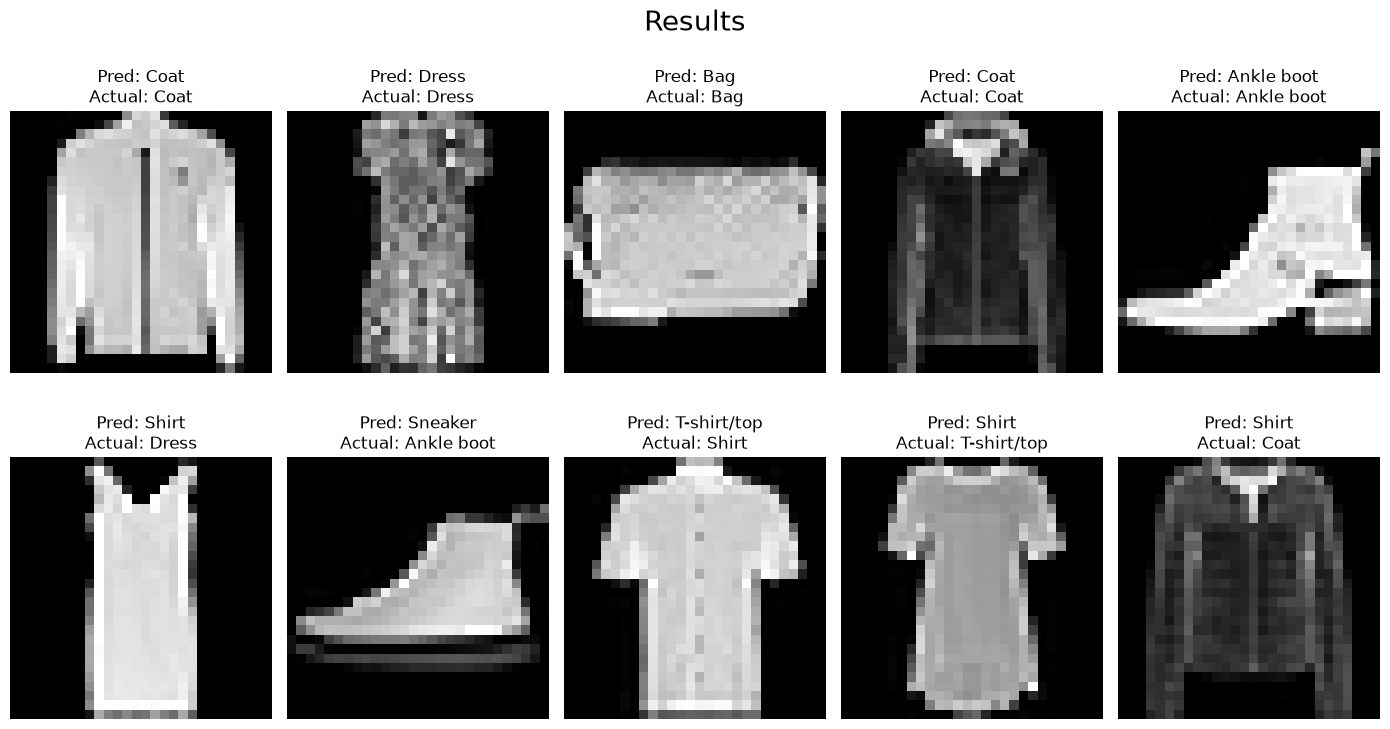

In [20]:
import random

num_correct = 5
num_wrong = 5

selected_correct = random.sample(correct_indices.tolist(), num_correct)
selected_wrong = random.sample(wrong_indices.tolist(), num_wrong)

selected_indices = selected_correct + selected_wrong



plt.figure(figsize=(14, 8))

for i, idx in enumerate(selected_indices):

    image = all_images[idx].squeeze()

    predicted_label = class_names[all_preds[idx]]
    actual_label = class_names[all_labels[idx]]

    plt.subplot(2, 5, i + 1)

    plt.imshow(image, cmap="gray")
    plt.axis("off")

    if all_preds[idx] == all_labels[idx]:
        title = f"Pred: {predicted_label}\nActual: {actual_label}"
    else:
        title = f"Pred: {predicted_label}\nActual: {actual_label}"

    plt.title(title, fontsize=12)

plt.suptitle("Results", fontsize=20)
plt.tight_layout()
plt.show()

In [21]:
torch.save(model.state_dict(), r"../models/cnn_baseline.pt")
print(f"CNN Baseline Model saved to models/cnn_baseline.pt")

CNN Baseline Model saved to models/cnn_baseline.pt
